# first test

In [820]:
# !python -m pip install seaborn

In [821]:
import pandas as pd
import numpy as np  # ← add this
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder


In [822]:
df = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [823]:
# df = df.rename(columns={'X1': 'item_Identifier', 'X2': 'item_Weight', 'X3': 'item_Fat_Content', 'X4': 'item_Visibility', 'X5': 'item_Type', 'X6': 'item_MRP', 'X7': 'outlet_Identifier', 'X8': 'outlet_Establishment_Year', 'X9': 'outlet_Size', 'X10': 'outlet_Location_Tier', 'X11': 'outlet_Type'})

In [824]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.23
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.09
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.65
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,6.60
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.90


In [825]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      6000 non-null   str    
 1   X2      4994 non-null   float64
 2   X3      6000 non-null   str    
 3   X4      6000 non-null   float64
 4   X5      6000 non-null   str    
 5   X6      6000 non-null   float64
 6   X7      6000 non-null   str    
 7   X8      6000 non-null   int64  
 8   X9      4289 non-null   str    
 9   X10     6000 non-null   str    
 10  X11     6000 non-null   str    
 11  Y       6000 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 562.6 KB


In [826]:
df.describe(include='all')

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y
count,6000,4994.000000,6000,6000.000000,6000,6000.000000,6000,6000.000000,4289,6000,6000,6000.000000
unique,1553,NaN,5,NaN,16,NaN,10,NaN,3,3,4,NaN
top,FDP28,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,OUT045,NaN,Medium,Tier 3,Supermarket Type1,NaN
freq,8,NaN,3595,NaN,875,NaN,677,NaN,1935,2358,3967,NaN
mean,NaN,12.956536,NaN,0.066333,NaN,141.228200,NaN,1997.840333,NaN,NaN,NaN,7.303403
std,NaN,4.658851,NaN,0.051492,NaN,62.540569,NaN,8.334412,NaN,NaN,NaN,1.014361
min,NaN,4.555000,NaN,0.000000,NaN,31.290000,NaN,1985.000000,NaN,NaN,NaN,3.510000
25%,NaN,8.895000,NaN,0.027030,NaN,94.037650,NaN,1987.000000,NaN,NaN,NaN,6.750000
50%,NaN,12.800000,NaN,0.054620,NaN,143.197000,NaN,1999.000000,NaN,NaN,NaN,7.500000
75%,NaN,17.100000,NaN,0.095154,NaN,186.522050,NaN,2004.000000,NaN,NaN,NaN,8.040000


In [827]:
df.duplicated().sum()

np.int64(0)

In [828]:
df.nunique()

X1     1553
X2      410
X3        5
X4     5577
X5       16
X6     4634
X7       10
X8        9
X9        3
X10       3
X11       4
Y       508
dtype: int64

In [829]:
item_fat_content = df['X3'].unique()
print(f"unique values in X3 : {item_fat_content} \n")
item_type = df['X5'].unique()
print(f"unique values in X5 : {item_type} \n")
outlet_identifier = df['X6'].unique()
print(f"unique values in X6 : {outlet_identifier} \n")
outlet_establishment_year = df['X8'].unique()
print(f"unique values in X8 : {outlet_establishment_year} \n")
outlet_size = df['X9'].unique()
print(f"unique values in X9 : {outlet_size} \n")
outlet_location_tier = df['X10'].unique()
print(f"unique values in X10 : {outlet_location_tier} \n")
outlet_type = df['X11'].unique()
print(f"unique values in X11 : {outlet_type} \n")

unique values in X3 : <StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str 

unique values in X5 : <StringArray>
[                'Dairy',           'Soft Drinks',                  'Meat',
 'Fruits and Vegetables',             'Household',          'Baking Goods',
           'Snack Foods',          'Frozen Foods',             'Breakfast',
    'Health and Hygiene',           'Hard Drinks',                'Canned',
                'Breads',         'Starchy Foods',                'Others',
               'Seafood']
Length: 16, dtype: str 

unique values in X6 : [249.8092  48.2692 141.618  ...  58.6246  60.4536 195.8452] 

unique values in X8 : [1999 2009 1998 1987 1985 2002 2007 1997 2004] 

unique values in X9 : <StringArray>
['Medium', nan, 'High', 'Small']
Length: 4, dtype: str 

unique values in X10 : <StringArray>
['Tier 1', 'Tier 3', 'Tier 2']
Length: 3, dtype: str 

unique values in X11 : <StringArray>
['Supermarket Type1', 'Supermarket Type2', 'Groce

In [830]:
x = df["X2"].mean()

df.fillna({"X2": x}, inplace=True)
# df.fillna({"outlet_Size": "Medium"}, inplace=True)
df['X9'] = df['X9'].fillna('Medium')

In [831]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      6000 non-null   str    
 1   X2      6000 non-null   float64
 2   X3      6000 non-null   str    
 3   X4      6000 non-null   float64
 4   X5      6000 non-null   str    
 5   X6      6000 non-null   float64
 6   X7      6000 non-null   str    
 7   X8      6000 non-null   int64  
 8   X9      6000 non-null   str    
 9   X10     6000 non-null   str    
 10  X11     6000 non-null   str    
 11  Y       6000 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 562.6 KB


In [832]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.23
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.09
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.65
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,6.60
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.90


In [833]:
# for x in df.index:
#   if df.loc[x, "item_Fat_Content"] =="low fat" or df.loc[x, "item_Fat_Content"] =="LF":
#     df.loc[x, "item_Fat_Content"] = "Low Fat"
#   elif df.loc[x, "item_Fat_Content"] =="reg":
#     df.loc[x, "item_Fat_Content"] = "Regular"
df['X3'] = df['X3'].replace({'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'})

In [834]:
x3 = df['X3'].unique() 
print(f"unique values in X3 : {x3} \n")

unique values in X3 : <StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str 



correlation

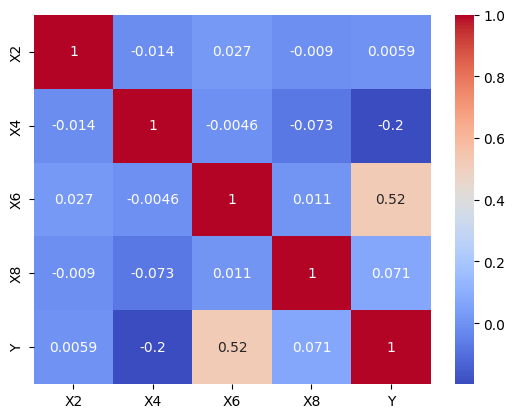

Mean Squared Error: 0.42165380689253384


In [835]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()
# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse) 

In [836]:
# Convert Establishment Year Ã¢â€ â€™ Outlet Age (more meaningful)
df['outlet_Age'] = 2026 - df['X8']

# Fix Item Visibility zeros (0 visibility is likely a data error)
# df['item_Visibility'] = df['item_Visibility'].replace(0, df['item_Visibility'].mean())
df['X4'] = df['X4'].replace(0, df[df['X4'] > 0]['X4'].mean())

In [837]:
df['log_X6']       = np.log1p(df['X6'])               # log MRP
df['log_X4']       = np.log1p(df['X4'])               # log visibility
# df['mrp_x_weight']  = df['X6'] * df['X2']             # MRP × item weight
# df['mrp_x_age']     = df['X6'] * df['outlet_Age']     # MRP × outlet age
# df['vis_x_age']     = df['X4'] * df['outlet_Age']

In [838]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y,outlet_Age,log_X6,log_X4
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.23,27,5.524692,0.015920
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.09,17,3.897299,0.019095
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.65,27,4.960170,0.016621
3,FDX07,19.20,Regular,0.070567,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,6.60,28,5.210005,0.068189
4,NCD19,8.93,Low Fat,0.070567,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.90,39,4.004810,0.068189


In [839]:
df['X9'] = df['X9'].map({'Small': 1, 'Medium': 2, 'High': 3})

In [840]:
tier_map = {'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1}
df['X10'] = df['X10'].map(tier_map)

# Result: 'Tier 1' = 3 (highest), 'Tier 2' = 2, 'Tier 3' = 1 (lowest)
print(df['X10'].value_counts())

X10
1    2358
2    1992
3    1650
Name: count, dtype: int64


In [841]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y,outlet_Age,log_X6,log_X4
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,2,3,Supermarket Type1,8.23,27,5.524692,0.015920
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,2,1,Supermarket Type2,6.09,17,3.897299,0.019095
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,2,3,Supermarket Type1,7.65,27,4.960170,0.016621
3,FDX07,19.20,Regular,0.070567,Fruits and Vegetables,182.0950,OUT010,1998,2,1,Grocery Store,6.60,28,5.210005,0.068189
4,NCD19,8.93,Low Fat,0.070567,Household,53.8614,OUT013,1987,3,1,Supermarket Type1,6.90,39,4.004810,0.068189


LOW FAT AND REGULAR

In [842]:
from sklearn.preprocessing import LabelEncoder

# cat_cols = ['item_Fat_Content']                            # Mean Squared Error: 0.41947350359700525

# le = LabelEncoder()                                   
# for col in cat_cols:
#     df[col] = le.fit_transform(df[col])

In [843]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
cat_cols = ['X3', 'X5', 'X9', 'X11']  # ← removed 'item_Identifier'

# Training
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Test
for col in cat_cols:
    le = encoders[col]
    mapping = {cat: idx for idx, cat in enumerate(le.classes_)}
    test[col] = test[col].astype(str).map(mapping).fillna(-1).astype(int)

In [844]:
df.head(15)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y,outlet_Age,log_X6,log_X4
0,FDA15,9.300000,0,0.016047,4,249.8092,OUT049,1999,1,3,1,8.23,27,5.524692,0.015920
1,DRC01,5.920000,1,0.019278,14,48.2692,OUT018,2009,1,1,2,6.09,17,3.897299,0.019095
2,FDN15,17.500000,0,0.016760,10,141.6180,OUT049,1999,1,3,1,7.65,27,4.960170,0.016621
3,FDX07,19.200000,1,0.070567,6,182.0950,OUT010,1998,1,1,0,6.60,28,5.210005,0.068189
4,NCD19,8.930000,0,0.070567,9,53.8614,OUT013,1987,2,1,1,6.90,39,4.004810,0.068189
5,FDP36,10.395000,1,0.070567,0,51.4008,OUT018,2009,1,1,2,6.32,17,3.958922,0.068189
6,FDO10,13.650000,1,0.012741,13,57.6588,OUT013,1987,2,1,1,5.84,39,4.071738,0.012661
7,FDP10,12.956536,0,0.127470,13,107.7622,OUT027,1985,1,1,3,8.30,41,4.689164,0.119976
8,FDH17,16.200000,1,0.016687,5,96.9726,OUT045,2002,1,2,1,6.98,24,4.584688,0.016549
9,FDU28,19.200000,1,0.094450,5,187.8214,OUT017,2007,1,2,1,8.46,19,5.240802,0.090252


In [845]:
#df = pd.get_dummies(df, columns=['item_Weight'], drop_first=True) #Mean Squared Error: 0.4427000828512708

In [846]:
x=df.drop(columns=['Y'])
y=df['Y']

x=pd.get_dummies(x)
x=x.fillna(x.mean())

In [847]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train , X_test , y_train ,y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.42165380689253384


Convert years to age

In [848]:
# df.drop(['item_Identifier', 'outlet_Identifier' , 'outlet_Establishment_Year'], axis=1, inplace=True)
df.drop(['X1', 'X7', 'X8', 'X10', 'X4' , 'X6'], axis=1, inplace=True)

Encoding Tiers

In [849]:
df.head(15)

,X2,X3,X5,X9,X11,Y,outlet_Age,log_X6,log_X4
0,9.300000,0,4,1,1,8.23,27,5.524692,0.015920
1,5.920000,1,14,1,2,6.09,17,3.897299,0.019095
2,17.500000,0,10,1,1,7.65,27,4.960170,0.016621
3,19.200000,1,6,1,0,6.60,28,5.210005,0.068189
4,8.930000,0,9,2,1,6.90,39,4.004810,0.068189
5,10.395000,1,0,1,2,6.32,17,3.958922,0.068189
6,13.650000,1,13,2,1,5.84,39,4.071738,0.012661
7,12.956536,0,13,1,3,8.30,41,4.689164,0.119976
8,16.200000,1,5,1,1,6.98,24,4.584688,0.016549
9,19.200000,1,5,1,1,8.46,19,5.240802,0.090252


In [850]:
model = LinearRegression()
model.fit(X_train, y_train)
print('Model trained on', X_train.shape[1], 'features')

Model trained on 1575 features


In [851]:
y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = model.score(X_test, y_test)

print(f'Mean Squared Error  (MSE)  : {mse:.6f}')
print(f'Root Mean Sq. Error (RMSE) : {rmse:.6f}')
print(f'R² Score                   : {r2:.4f}')

Mean Squared Error  (MSE)  : 0.421654
Root Mean Sq. Error (RMSE) : 0.649349
R² Score                   : 0.6073
